## Assignment 2: $k$ Nearest Neighbor

### Do any four.

**Q1.** Please answer the following questions.
1. **What is the difference between regression and classification?** In supervised learning, if the target/outcome variable y (which we are using predict using x) is a categorical variable, then we are doing classification. An example would be predicting disease based on patient symptoms. If y is a numerical variable, then we are doing regression. An example of this would be predicting car sales from price and miles-per-gallon.
2. **What is a confusion table/matrix? What does it help us understand about a model's performance?** A confusion table/matrix is a matrix that shows how the classification model's predictions compare to the actual values. To do this, you cross-tabulate the true labels with the predicted ones, then look at the amounts and how much they differ. This helps us understand how many predictions were correct or incorrect by class.
3. **What is Accuracy? Why might it not be entirely sufficient to evaluate a classifer's predictive performance?** Accuracy is the proporation of cases we predicted accurately. To do this, you sum up the number of cases on the descending diagonal (of the confusion matrix) and divide it by the total number of observations. This creates a single number that defines how accurate the model is. This may not be entirely sufficient because a single number doesn't tell us the types of mistakes the model made. It doesn't come with a lot of information on how to fix the model to make it more accurate.
4. **What does the root mean squared error quantify about a particular model?** The root mean squared error is the distance from the true values to the predicted ones, weighted by sample size. This creates a summary number for our regression model. The lower the number, the better, because it indicates a better fit between the true values and the predicted values.
5. **What are overfitting and underfitting?** Overfitting is when a model is overly sensitive to a certain selection of data points due to selecting a k (hyper-parameter) that is too low. On the other hand, underfitting is when the model averages over many observations and gives answers close to population proportions due to selecting a k that is too high. We do not want to overfit nor underfit our models.
6. **Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or RMSE on the test set, improve model performance?** This improves performance because it allows you to evaluate the models on new data. This allows us to choose a k that avoids overfitting and that generalizes better.
7. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.** The strenghts of predicting a class label are that it is simple and easy to intepret and you can use it directly. Its weaknesses are that there is no information about its confidence and it is less informative. For probability distribution over class labels, its strengths are that it tells you the confidence, there are flexible decision thresholds, and it is more informative overall. Its weaknesses are that it is a little more difficult to intepret and the probabilities might not be accurate.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the relationships between the features (e.g. scatterplots, describe tables).
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. **Build a $k$-NN classifier. Explain how you select $k$.** To select the best k, I first split the data using a train-test split to replicate uncertainty. Then, I trained the model on a k value. After, I looped over k to evaluate the accuracy of k with new data.
I selected k by evaluting values of k from 1-31 and selected the value that produced the highest accuracy on the test set.

4. **Print a confusion table for your best model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?** The confusion table indicates that the model is about 54% accurate. This was done by summing the diagonal and dividing that by the total sum. Looking at the table, it performs best with mine type 1 and 2, and the worst with mine type 4.
5. **Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.** I would advise someone to use the model in helping them make decisions, but not let it be a key factor. Additionally, I would make sure they understand that the model is better at predicting with mine tpes 1 and 2, but worse at 3 and 4. This would be an important consideration when utilizing the model.

In [2]:
! git clone https://github.com/katiehutc/scratchpad
%run ./scratchpad/get_data.py

Cloning into 'scratchpad'...
remote: Enumerating objects: 36, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 36 (delta 7), reused 5 (delta 5), pack-reused 24 (from 2)
Receiving objects: 100% (36/36), 56.78 KiB | 6.31 MiB/s, done.
Resolving deltas: 100% (9/9), done.
Download complete
Extracting data files...
Data extracted


    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB
None
          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000 

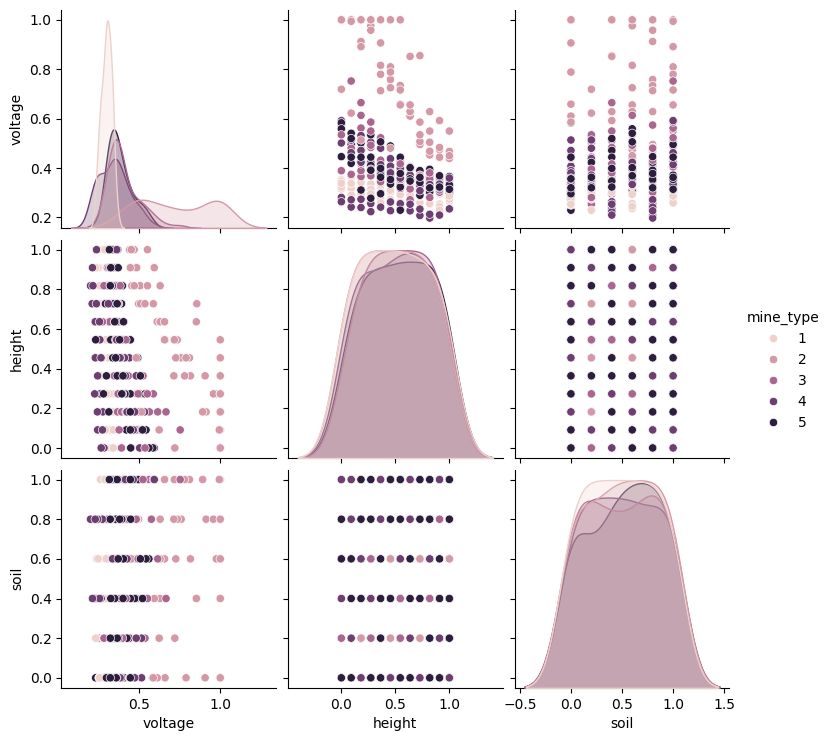

In [ ]:
# Part 1
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/data/land_mines.csv', encoding = 'latin1')

print(df.head())
print(df.info())
print(df.describe())
print(df["mine_type"].value_counts())
sns.pairplot(df, hue="mine_type")
plt.show()


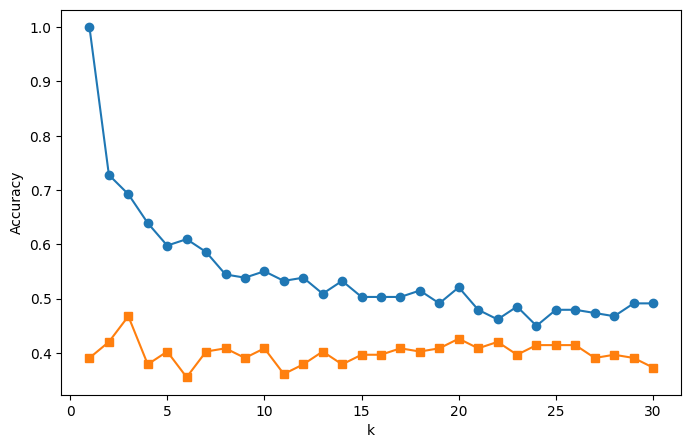

col_0       1   2   3  4  5
mine_type                  
1          26   0   4  2  4
2           0  30   2  2  1
3          12   3  10  1  7
4           9   4  10  8  2
5          10   1  14  2  5
0.46745562130177515


In [ ]:
# Part 2
import numpy as np
import matplotlib.pyplot as plt

y = df['mine_type']
ctrl_list = ['voltage','height','soil']
x = df.loc[:, ctrl_list]

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
u = scaler.fit_transform(x)

from sklearn.model_selection import train_test_split

u_train, u_test, y_train, y_test = train_test_split(
    u, y,
    test_size=.5,
    random_state=100,
    stratify=y
)
# Part 3
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_grid = np.arange(1,31)
test_accuracies = []
train_accuracies = []

for k in k_grid:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(u_train, y_train)

    y_train_pred = model.predict(u_train)
    y_test_pred = model.predict(u_test)

    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(8,5))
plt.plot(k_grid, train_accuracies, marker='o', label='Training Accuracy')
plt.plot(k_grid, test_accuracies, marker='s', label='Test Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.show()

best_k = k_grid[np.argmax(test_accuracies)]
best_k

# retrain with best k
model = KNeighborsClassifier(n_neighbors=best_k)
model = model.fit(u_train, y_train)
y_hat = model.predict(u_test)

# Part 4
print(pd.crosstab(y_test, y_hat))

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_hat))


**Q3.** This question is a case study for $k$ nearest neighbor regression, using the `USA_cars_datasets.csv` data.

The target variable `y` is `price` and the features are `year` and `mileage`.

1. Load the `./data/USA_cars_datasets.csv`. Keep the following variables and drop the rest: `price`, `year`, `mileage`. Are there any `NA`'s to handle? Look at the head and dimensions of the data.
2. Maxmin normalize `year` and `mileage`.
3. Split the sample into ~80% for training and ~20% for hyper-parameter selection and evaluation.
4. **Use the $k$-NN algorithm and the training data to predict `price` using `year` and `mileage` for the test set for $k=3,10,25,50,100,300$. For each value of $k$, compute the mean squared error and print a scatterplot showing the test value plotted against the predicted value. What patterns do you notice as you increase $k$?**
As you increase k, the predicted price values appear to be decreasing in slope. With a small k, the predictions were steep and variable, closely following individual data points, indicating overfitting. As k increased, the model smoothed out the predictions, and at very large k, the slope decreased significantly, leading to underfitting.
5. **Determine the optimal $k$ for these data.** The optimal k was 50.
6. **Describe what happened in the plots of predicted versus actual prices as $k$ varied, taking your answer into part 6 into account. (Hint: Use the words "underfitting" and "overfitting".)**
As k increased, the predictions from the k-NN model became progressively flatter. For small values of k , the model closely followed individual data points, resulting in a steep and highly variable slope; this reflects overfitting, where the model captures noise in the training data. As k increased to moderate values, the predictions smoothed out, the slope approached 1, and the MSE on the test set reached its minimum, indicating the best balance between bias and variance. For very large  k values, the slope decreased significantly, extreme prices were under or overestimated, and the MSE increased again, indicating underfitting, because the model is too smooth and cannot capture the variability in car prices. Therefore, the optimal  k corresponds to the value with the lowest MSE, as it minimizes prediction error while avoiding both overfitting and underfitting.

price      0
year       0
mileage    0
dtype: int64
   price  year  mileage
0   6300  2008   274117
1   2899  2011   190552
2   5350  2018    39590
3  25000  2014    64146
4  27700  2018     6654
(2499, 3)


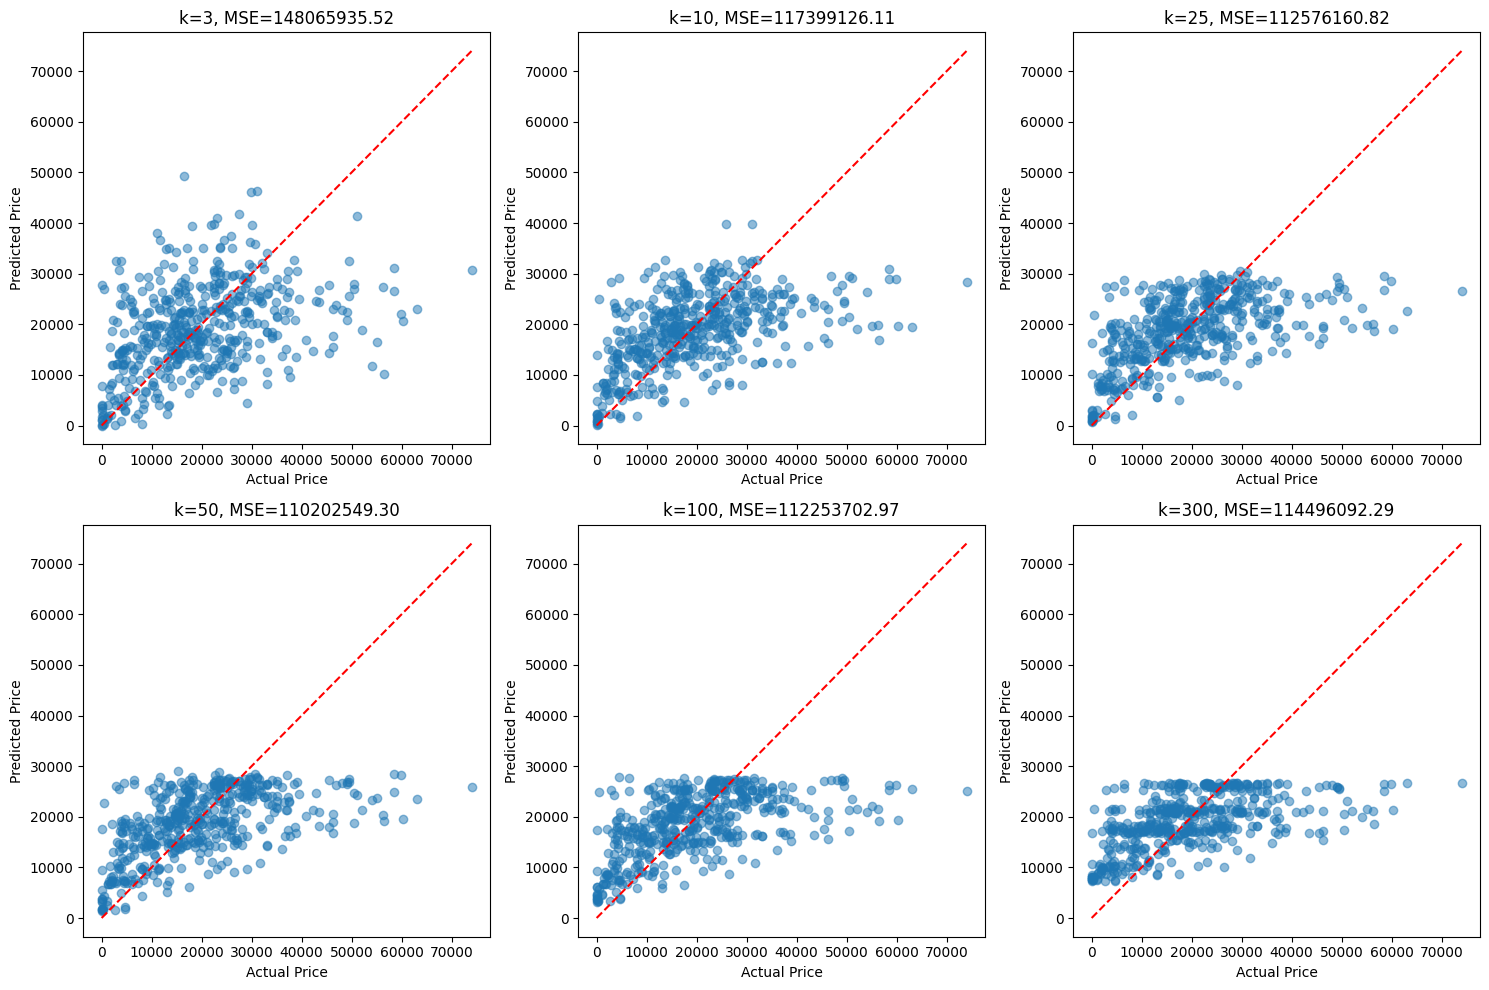

Optimal k: 50, with MSE=110202549.30
k=3, MSE=148065935.52
k=10, MSE=117399126.11
k=25, MSE=112576160.82
k=50, MSE=110202549.30
k=100, MSE=112253702.97
k=300, MSE=114496092.29


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Part 1
df = pd.read_csv('/content/data/USA_cars_datasets.csv', encoding = 'latin1')
df = df[['price', 'year', 'mileage']]
print(df.isna().sum())

print(df.head())
print(df.shape)

# Part 2
scaler = MinMaxScaler()
df[['year', 'mileage']] = scaler.fit_transform(df[['year', 'mileage']])

# Part 3
X = df[['year', 'mileage']]
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Part 4
k_values = [3, 10, 25, 50, 100, 300]
mse_list = []

plt.figure(figsize=(15,10))

for i, k in enumerate(k_values, 1):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    mse_list.append(mse)

    # Scatterplot of predicted vs actual prices
    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
    plt.xlabel('Actual Price')
    plt.ylabel('Predicted Price')
    plt.title(f'k={k}, MSE={mse:.2f}')

plt.tight_layout()
plt.show()

# Part 5
best_k = k_values[np.argmin(mse_list)]
print(f"Optimal k: {best_k}, with MSE={min(mse_list):.2f}")

# Part 6
for k, mse in zip(k_values, mse_list):
    print(f"k={k}, MSE={mse:.2f}")

**Q4.** This question is a case study for $k$ nearest neighbor regression, using the `heart_failure_clinical_records_dataset.csv` data.

The data for the question include:

- age: age of the patient (years)
- anaemia: decrease of red blood cells or hemoglobin (boolean)
- high blood pressure: if the patient has hypertension (boolean)
- creatinine phosphokinase (CPK): level of the CPK enzyme in the blood (mcg/L)
- diabetes: if the patient has diabetes (boolean)
- ejection fraction: percentage of blood leaving the heart at each contraction (percentage)
- platelets: platelets in the blood (kiloplatelets/mL)
- sex: woman or man (binary)
- serum creatinine: level of serum creatinine in the blood (mg/dL)
- serum sodium: level of serum sodium in the blood (mEq/L)
- smoking: if the patient smokes or not (boolean)
- time: follow-up period (days)
- death event: if the patient deceased during the follow-up period (boolean)

1. Load the `./data/heart_failure_clinical_records_dataset.csv`. Are there any `NA`'s to handle? use `.drop()` to remove `time` from the dataframe.
2. Make a correlation matrix. What variables are strongly associated with a death event?
3. For the dummy variables `anaemia`, `diabetes`, `high_blood_pressure`, `sex`, and `smoking`, compute a summary table of `DEATH_EVENT` grouped by the variable. For which variables does a higher proportion of the population die when the variable takes the value 1 rather than 0?
4. On the basis of your answers from 2 and 3, build a matrix $X$ of the variables you think are most predictive of a death, and a variable $y$ equal to `DEATH_EVENT`.
5. Maxmin normalize all of the variables in `X`.
6. Split the sample into ~80% for training and ~20% for evaluation. (Try to use the same train/test split for the whole question, so that you're comparing apples to apples in the questions below.).
7. Determine the optimal number of neighbors for a $k$-NN classification or regression for the variables you selected.
8. OK, do steps 5 through 7 again, but use all of the variables (except `time`). Which model has the best Mean Squared Error? Which would you prefer to use in practice, if you had to predict `DEATH_EVENT`s? If you play with the selection of variables, how much does the RMSE change for your fitted model on the test data? Are more variables always better? Explain your findings.

**Q5.** This is a case study on $k$ nearest neighbor classification, using the `animals.csv` data.

The data consist of a label, `class`, taking integer values 1 to 7, the name of the species, `animal`, and 16 characteristics of the animal, including `hair`, `feathers`, `milk`, `eggs`, `airborne`, and so on.

1. Load the data. For each of the seven class labels, print the values in the class and get a sense of what is included in that group. Perform some other EDA: How big are the classes? How much variation is there in each of the features/covariates? Which variables do you think will best predict which class?
2. Split the data 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be. Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Using all of the variables, build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion matrix for the optimal model, comparing predicted and actual class label on the test set. How accurate it is? Can you interpret why mistakes are made across groups?
5. Use only `milk`, `aquatic`, and `airborne` to train a new $k$-NN classifier. Print your confusion table. Mine does not predict all of the classes, only a subset of them. To see the underlying proportions/probabilities, use `model.predict_proba(X_test.values)` to predict probabilities rather than labels for your `X_test` test data for your fitted `model`. Are all of the classes represented? Explain your results.

**Q6.** This is a case study using $k$ nearest neighbor regression for imputation, using the `airbnb_hw.csv` data.

There are 30,478 observations, but only 22,155 ratings. We're going to build a kNN regressor to impute missing values. This is a common task, and illustrates one way you can use kNN in the future even when you have more advanced models available.

1. Load the `airbnb_hw.csv` data with Pandas. We're only going to use `Review Scores Rating`, `Price`, and `Beds`, so use `.loc` to column filter the dataframe to those variables.
2. Set use `.isnull()` and `.loc` to select the subset of the dataframe with missing review values. Set those aside in a different dataframe. We'll make predictions about them later.
3. Use `df = df.dropna(axis = 0, how = 'any')` to eliminate any observations with missing values/NA's from the dataframe.
4. For the complete cases, create a $k$-NN model that uses the variables `Price` and `Beds` to predict `Review Scores Rating`. How do you choose $k$? (Hint: Train/test split, iterate over reasonable values of $k$ and find a value that minimizes SSE on the test split using predictions from the training set.)
5. Predict the missing ratings.
6. **Do a kernel density plot of the training ratings and the predicted missing ratings. Do they look similar or not? Describe what you see.**
Looking at the kernel density plot of the training ratings and the predicted missing ratings, the two plots do not look very similar. The observed ratings has a much lower comparative density, while the predicted missing ratings peaks much higher. This indicates that the observed ratings are more varied and spread out, and the predicted missing ratings avoid more extreme values as it has less variance.

best k = 241


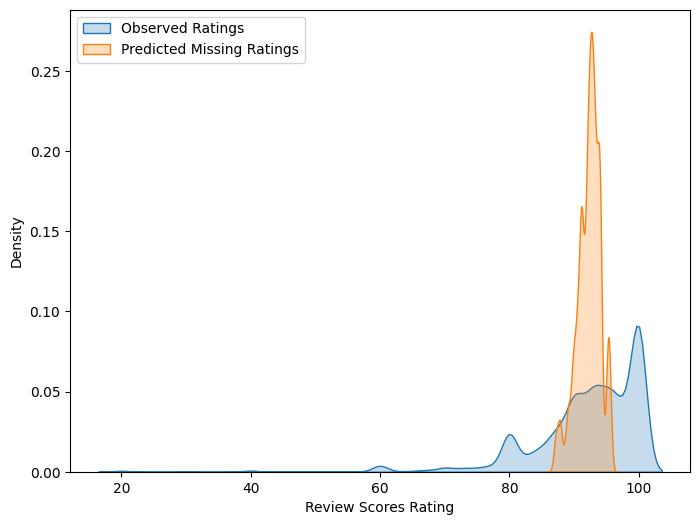

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

# Part 1
df = pd.read_csv('/content/data/airbnb_hw.csv', encoding='latin1')
df = df.loc[:, ['Review Scores Rating', 'Price', 'Beds']]

# fix numbers with commas first
df['Price'] = df['Price'].astype(str).str.replace(',', '', regex=False)
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Part 2
missing_df = df.loc[df['Review Scores Rating'].isnull()]

# Part 3
complete_df = df.dropna(axis=0, how='any')

# Part 4
X = complete_df[['Price', 'Beds']]
y = complete_df['Review Scores Rating']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=100
)

k_grid = np.arange(1,301,2)
test_mses = []
train_mses = []

for k in k_grid:
    model = KNeighborsRegressor(n_neighbors=k)
    model = model.fit(X_train, y_train)

    y_hat_test = model.predict(X_test)
    y_hat_train = model.predict(X_train)

    mse_test = mean_squared_error(y_test, y_hat_test)
    mse_train = mean_squared_error(y_train, y_hat_train)

    test_mses.append(mse_test)
    train_mses.append(mse_train)

best_k = k_grid[np.argmin(test_mses)]
print("best k =", best_k)

# Part 5
X_full_scaled = scaler.fit_transform(complete_df[['Price', 'Beds']])
model = KNeighborsRegressor(n_neighbors=best_k)
model.fit(X_full_scaled, complete_df['Review Scores Rating'])

missing_df = missing_df.dropna(subset=['Price','Beds'])

X_missing_scaled = scaler.transform(missing_df[['Price', 'Beds']])
missing_df['Predicted Rating'] = model.predict(X_missing_scaled)

# Part 6
plt.figure(figsize=(8,6))
sns.kdeplot(complete_df['Review Scores Rating'], label="Observed Ratings", fill=True)
sns.kdeplot(missing_df['Predicted Rating'], label="Predicted Missing Ratings", fill=True)
plt.xlabel("Review Scores Rating")
plt.ylabel("Density")
plt.legend()
plt.show()


**Q7.** Let's do some very basic computer vision. We're going to import the MNIST handwritten digits data and use $k$-NN to predict values (i.e. "see/read").

1. To load the data, run the following code in a chunk:
```
from keras.datasets import mnist
df = mnist.load_data('minst.db')
train,test = df
X_train, y_train = train
X_test, y_test = test
```
The `y_test` and `y_train` vectors, for each index `i`, tell you want number is written in the corresponding index in `X_train[i]` and `X_test[i]`. The value of `X_train[i]` and `X_test[i]`, however, is a 28$\times$28 array whose entries contain values between 0 and 256. Each element of the matrix is essentially a "pixel" and the matrix encodes a representation of a number. To visualize this, run the following code to see the first ten numbers:
```
import matplotlib.pyplot as plt
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=100000)
for i in range(5):
    print(y_test[i],'\n') # Print the label
    print(X_test[i],'\n') # Print the matrix of values
    plt.contourf(np.rot90(X_test[i].transpose())) # Make a contour plot of the matrix values
    plt.show()
```
OK, those are the data: Labels attached to handwritten digits encoded as a matrix.

2. What is the shape of `X_train` and `X_test`? What is the shape of `X_train[i]` and `X_test[i]` for each index `i`? What is the shape of `y_train` and `y_test`?
3. Use Numpy's `.reshape()` method to covert the training and testing data from a list of matrix into an vector of features. So, `X_test[index].reshape((1,784))` will convert the $index$-th element of `X_test` into a $28\times 28=784$-length row vector of values, rather than a matrix. Turn `X_train` into an $N \times 784$ matrix $X$ that is suitable for scikit-learn's kNN classifier where $N$ is the number of observations and $784=28*28$ (you could use, for example, a `for` loop).
4. Use the reshaped `X_test` and `y_test` data to create a $k$-nearest neighbor classifier of digit. What is the optimal number of neighbors $k$? If you can't determine this, play around with different values of $k$ for your classifier.
5. For the optimal number of neighbors, how well does your predictor perform on the test set? Report the accuracy, compute a confusion matrix, and explain your findings.
6. For your confusion matrix, which mistakes are most likely? Do you find any interesting patterns?
7. So, this is how computers "see." They convert an image into a matrix of values, that matrix becomes a vector in a dataset, and then we deploy ML tools on it as if it was any other kind of tabular data. To make sure you follow this, invent a way to represent a color photo in matrix form, and then describe how you could convert it into tabular data. (Hint: RGB color codes provide a method of encoding a numeric value that represents a color.)